In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ GPU aktif")
else:
    print("❌ GPU yok")


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU aktif


In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 64

CLASSES = ["angry","disgust","fear","happy","neutral","sad","surprise"]

DATA_ROOT = "datasets"
FER_DIR   = os.path.join(DATA_ROOT, "fer")
KDEF_DIR  = os.path.join(DATA_ROOT, "kdef")
JAFFE_DIR = os.path.join(DATA_ROOT, "jaffe")


In [4]:
def load_test_ds(base_dir):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(base_dir, "test"),
        labels="inferred",
        label_mode="int",
        class_names=CLASSES,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    def _pp(x, y):
        x = tf.cast(x, tf.float32)
        x = preprocess_input(x)
        return x, y

    ds = ds.map(_pp, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

fer_test   = load_test_ds(FER_DIR)
kdef_test  = load_test_ds(KDEF_DIR)
jaffe_test = load_test_ds(JAFFE_DIR)

# birleşik test
test_ds = fer_test.concatenate(kdef_test).concatenate(jaffe_test)


Found 11485 files belonging to 7 classes.
Found 441 files belonging to 7 classes.
Found 32 files belonging to 7 classes.


In [5]:
valence_model = tf.keras.models.load_model("best_valence.keras")
neg_model     = tf.keras.models.load_model("best_neg4.keras")
ns_model      = tf.keras.models.load_model("best_ns2.keras")

print("✅ Modeller yüklendi")


✅ Modeller yüklendi


In [6]:
y_true_all = []
y_pred_all = []

for xb, yb in test_ds:
    xb = tf.cast(xb, tf.float32)
    y_true_all.append(yb.numpy())

    # 1️⃣ Valence prediction
    pv = valence_model.predict(xb, verbose=0)
    v_cls = np.argmax(pv, axis=1)  # 0 neg, 1 neu, 2 pos

    batch_pred = np.empty_like(v_cls)

    # 2️⃣ Positive → happy
    pos_mask = (v_cls == 2)
    batch_pred[pos_mask] = CLASSES.index("happy")

    # 3️⃣ Neutral → ns2
    neu_mask = (v_cls == 1)
    if np.any(neu_mask):
        X_neu = xb[neu_mask]
        pns = ns_model.predict(X_neu, verbose=0)
        ns = np.argmax(pns, axis=1)
        batch_pred[neu_mask] = np.where(
            ns == 1,
            CLASSES.index("surprise"),
            CLASSES.index("neutral")
        )

    # 4️⃣ Negative → neg4
    neg_mask = (v_cls == 0)
    if np.any(neg_mask):
        X_neg = xb[neg_mask]
        png = neg_model.predict(X_neg, verbose=0)
        ng = np.argmax(png, axis=1)
        neg_back = [
            CLASSES.index("angry"),
            CLASSES.index("disgust"),
            CLASSES.index("fear"),
            CLASSES.index("sad")
        ]
        batch_pred[neg_mask] = np.array([neg_back[i] for i in ng])

    y_pred_all.append(batch_pred)

y_true = np.concatenate(y_true_all)
y_pred = np.concatenate(y_pred_all)

print("✅ Cascade inference tamamlandı")


✅ Cascade inference tamamlandı


=== CASCADE TEST REPORT (7-class) ===
              precision    recall  f1-score   support

       angry     0.4607    0.5052    0.4819      1625
     disgust     0.7019    0.4669    0.5608       242
        fear     0.4654    0.4175    0.4402      1710
       happy     0.8556    0.7458    0.7969      2923
     neutral     0.5548    0.4871    0.5187      2047
         sad     0.4261    0.5732    0.4888      2041
    surprise     0.6899    0.7000    0.6949      1370

    accuracy                         0.5815     11958
   macro avg     0.5935    0.5565    0.5689     11958
weighted avg     0.5992    0.5815    0.5864     11958

Macro-F1: 0.5689073496275255


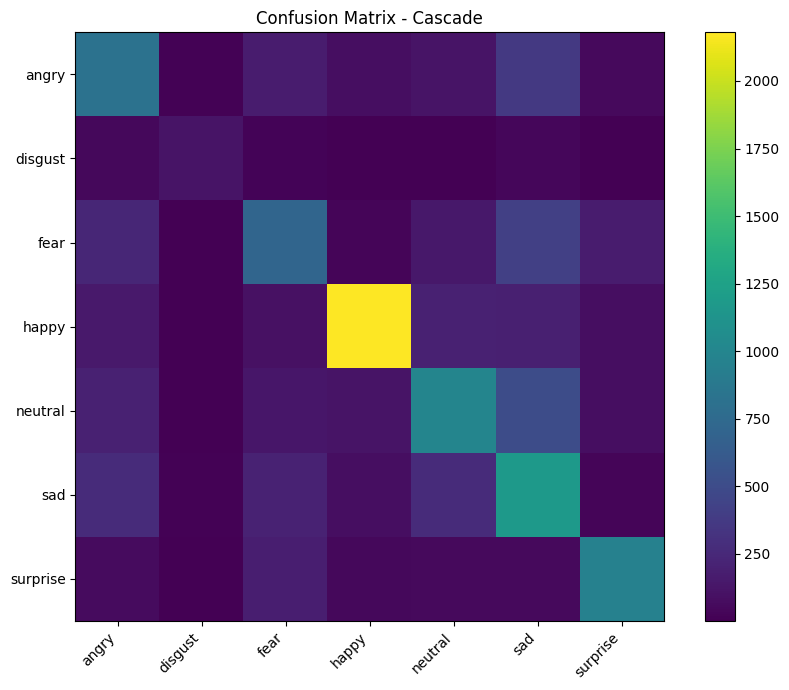

In [7]:
print("=== CASCADE TEST REPORT (7-class) ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

print("Macro-F1:", f1_score(y_true, y_pred, average="macro"))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
plt.imshow(cm)
plt.title("Confusion Matrix - Cascade")
plt.xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
plt.yticks(range(len(CLASSES)), CLASSES)
plt.colorbar()
plt.tight_layout()
plt.show()
